<a href="https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/CLIPSeg/Zero_shot_image_segmentation_with_CLIPSeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set-up environment

Let's first install the required packages.

In [ ]:
!pip install -q transformers

## Load image

Next, let's load an image.

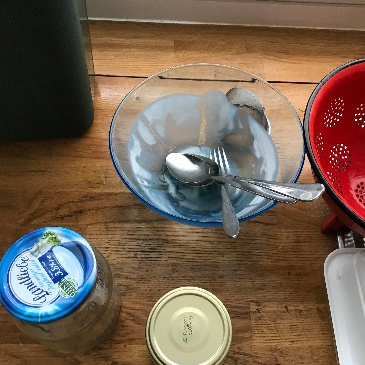

In [1]:
from PIL import Image
import requests

url = "https://github.com/timojl/clipseg/blob/master/example_image.jpg?raw=true"
image = Image.open(requests.get(url, stream=True).raw)
image

## Load model

Next, let's load the model and its processor from the [hub](https://huggingface.co/CIDAS/clipseg-rd64-refined).

In [8]:
import torch
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined", use_fast=True)
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

## Prepare image and texts for model

The image and a few prompts can be prepared for the model using the processor.

In [4]:
prompts = ["a glass", "something to fill", "wood", "a jar"]

inputs = processor(text=prompts, images=[image] * len(prompts), padding=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

/Users/nielsrogge/Documents/python_projecten/Transformers-Tutorials/.venv/lib/python3.12/site-packages/transformers/image_processing_utils.py:51: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)


## Forward pass

Next, let's run a forward pass and visualize the predictions the model made.

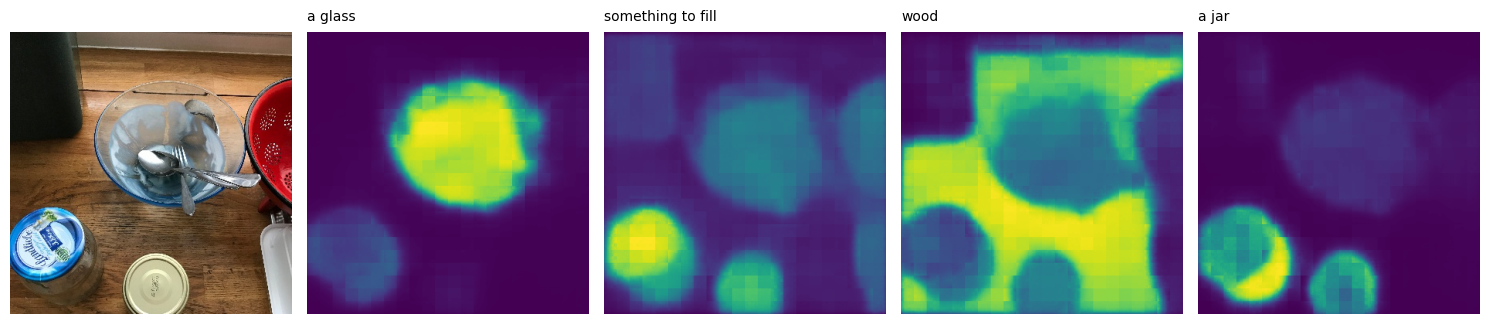

In [5]:
import matplotlib.pyplot as plt

with torch.no_grad():
    outputs = model(**inputs)

preds = outputs.logits.unsqueeze(1)

# visualize prediction
fig, ax = plt.subplots(1, 5, figsize=(15, 4))
for a in ax.flatten():
    a.axis('off')
ax[0].imshow(image)
for i in range(4):
    ax[i + 1].imshow(torch.sigmoid(preds[i][0]).cpu())
    ax[i + 1].text(0, -15, prompts[i])
plt.tight_layout()
plt.show()

As can be seen, the model is capable of segmenting images based on text prompts in a zero-shot manner.

## Convert to binary mask

To convert the prediction to a binary mask, we can apply a sigmoid activation function and threshold the values.

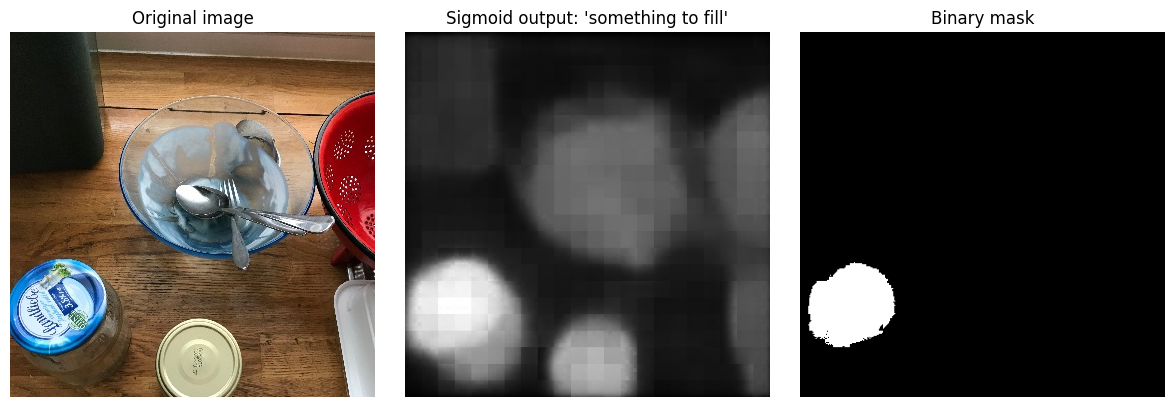

In [6]:
import numpy as np

# Select which prompt's mask to convert (index 1 = "something to fill")
mask_index = 1
threshold = 0.5

# Apply sigmoid and threshold to create binary mask
sigmoid_output = torch.sigmoid(preds[mask_index][0]).cpu().numpy()
binary_mask = (sigmoid_output > threshold).astype(np.uint8) * 255

# Display the binary mask
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image)
ax[0].set_title("Original image")
ax[0].axis('off')
ax[1].imshow(sigmoid_output, cmap='gray')
ax[1].set_title(f"Sigmoid output: '{prompts[mask_index]}'")
ax[1].axis('off')
ax[2].imshow(binary_mask, cmap='gray')
ax[2].set_title("Binary mask")
ax[2].axis('off')
plt.tight_layout()
plt.show()

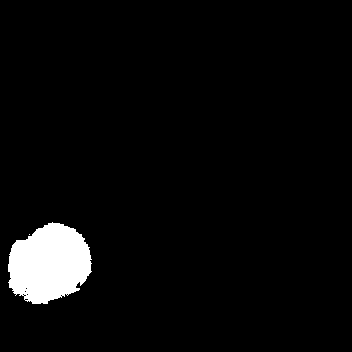

In [7]:
# Display the binary mask as PIL Image
Image.fromarray(binary_mask)